**%%% How is the success rate of NFL kickers making 50 yard field goals in domes vs outdoor stadiums from 2023-2024? ****

In [86]:
%pip install nflreadpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 


Note: you may need to restart the kernel to use updated packages.


 A summary about the first line of the code and visuals. This project looks at whether NFL kickers are more successful on 50+ yard field goals in dome or outdoor stadiums from 2022 to 2024. The dataset includes play-by-play NFL data, and the main variables are kick distance, field goal result, and stadium type. Each row represents one field goal attempt. The purpose of this analysis is to compare how often kickers make long field goals in different environments and to see whether stadium conditions affect performance. This is important because kicking success can directly influence game outcomes, especially in close games. The data comes from official NFL play-by-play records and was filtered to only include field goals from 50 yards or farther. This makes the analysis focused on the specific question of whether long kicks are easier or harder depending on stadium type. This dataset is useful because it connects raw game information to a real sports question. It shows that distance is a major factor in success, and by separating dome/indoor and outdoor attempts, we can compare how different conditions may affect kicking performance. Overall, the data helps explain how environmental factors influence long-distance kicking in the NFL. 

In [87]:
import nflreadpy as nfl
import polars as pl

seasons = list(range(2022,2023,2024))
pbp = nfl.load_pbp(seasons)
df = pbp.to_pandas()


In [88]:
fg_df = df[
    (df['play_type'] == 'field_goal') & 
    (df['kick_distance'] >= 50)
].copy()

In [89]:
fg_df = df[
    (df['play_type'] == 'field_goal') & 
    (df['kick_distance'] >= 50)
].copy()

In [90]:
dome_types = ['dome', 'closed']
fg_df['roof_type'] = fg_df['roof'].apply(
    lambda x: 'Dome/Indoors' if str(x).lower() in dome_types else 'Outdoor'
)
fg_df.loc[fg_df['roof_type'] == 'Dome/Indoors', 'wind'] = 0
fg_df['wind'] = fg_df['wind'].fillna(fg_df['wind'].median())

In [91]:
clean_fg = (
    fg_df.loc[:, [
        'game_id', 'season', 'kicker_player_name',
        'kick_distance', 'roof_type', 'wind', 'field_goal_result'
    ]]
    .rename(columns={'field_goal_result': 'is_make'})
    .assign(is_make=lambda d: d['is_make'].eq('made'))
    .dropna(subset=['game_id', 'season', 'kicker_player_name', 'kick_distance', 'roof_type', 'wind'])
)
print(f"Cleaned dataset shape: {clean_fg.shape}")

Cleaned dataset shape: (229, 7)


  My  variable is_make vs miss
This first Visual Tracks the attempt result (1 for success, 0 for miss/blocked). This serves as your primary outcome variable, allowing you to calculate and compare overall conversion percentages (Makes/Total Attempts) across the two stadium types. Also the distance each field goal is being kicked. Two questions that need to be answered. What is the context surrounding this problem? What do we need to know to understand
this issue? Why is this question relevant, and who would care about these findings? The context surrounding this problem is sucess for made vs missed field goal in both indoor and outdoor stadiums seeing stats on makes and misses during the 2022-2024 seasons. The question is relevant because it gives us accurate data on how kickers performed during the season and how far they could kick from distance wise. 


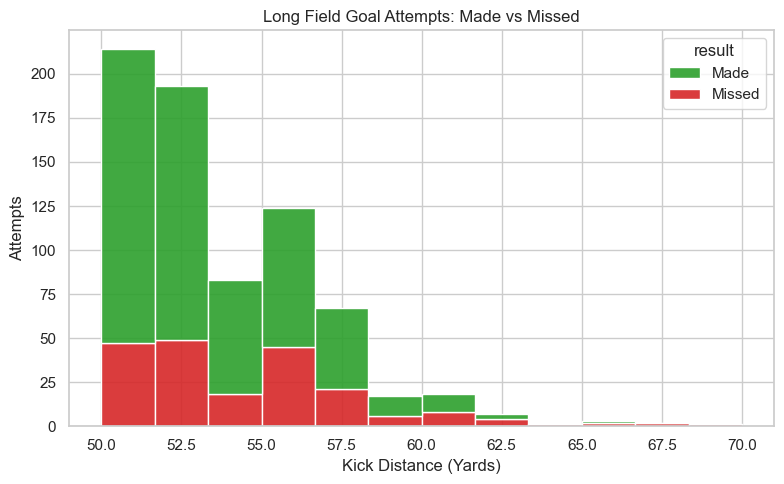

In [92]:
pbp = nfl.load_pbp([2022, 2023, 2024])

long_fg = (
    pbp.filter(
        (pl.col("play_type") == "field_goal")
        & (pl.col("kick_distance") >= 50)
        & (pl.col("field_goal_result").is_in(["made", "missed"]))
    )
    .to_pandas()
    .copy()
)

long_fg["result"] = long_fg["field_goal_result"].map({"made": "Made", "missed": "Missed"})

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=long_fg,
    x="kick_distance",
    hue="result",
    bins=12,
    multiple="stack",
    palette={"Made": "#2ca02c", "Missed": "#d62728"},
    edgecolor="white",
    alpha=0.9,
    ax=ax,
    legend=True,
)

ax.set_title("Long Field Goal Attempts: Made vs Missed")
ax.set_xlabel("Kick Distance (Yards)")
ax.set_ylabel("Attempts")

plt.tight_layout()
plt.show()

In [93]:
pbp = nfl.load_pbp([ 2022, 2023, 2024])

 My variable for this visual is sucess_rate_pct this tracks the percentage of success rate from indoor stadiums compared to outdoor stadiums. Two questions to ask for this are What is the context surrounding this problem? What do we need to know to understand
this issue? Why is this question relevant, and who would care about these findings? The context surrounding this problem is what is the success rate from indoor stadiums compared to outdoor. Nfl teams would care to see these findings because it shows and accurate percentage of field goals in indoor stadium compared to out door stadiums. 

This second visual of the project examines whether NFL kickers are more successful on 50+ yard field goals in dome/indoor stadiums compared to outdoor stadiums from 2022 to 2024. The dataset includes official NFL play-by-play data, and the key variables are kick distance, field goal result, and stadium type. Each row represents one field goal attempt, and the analysis focuses on attempts from 50 yards or farther. This question is important because long field goals can decide game outcomes, and stadium conditions may affect kicking accuracy. The data was filtered to long attempts so the comparison between indoor and outdoor performance is clear and meaningful.

shape: (2, 4)
┌──────────────┬────────────────┬───────────────┬──────────────────┐
│ venue_type   ┆ total_attempts ┆ made_attempts ┆ success_rate_pct │
│ ---          ┆ ---            ┆ ---           ┆ ---              │
│ str          ┆ u32            ┆ u32           ┆ f64              │
╞══════════════╪════════════════╪═══════════════╪══════════════════╡
│ Dome/Indoors ┆ 83             ┆ 64            ┆ 77.11            │
│ Outdoor      ┆ 146            ┆ 95            ┆ 65.07            │
└──────────────┴────────────────┴───────────────┴──────────────────┘


/var/folders/09/z7bb5zsx1cn15379j711wzmc0000gn/T/ipykernel_11087/2419565157.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


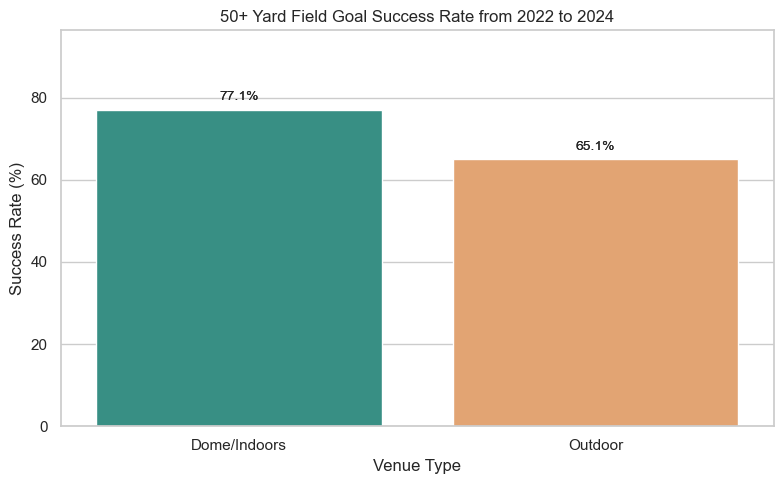

In [94]:
summary = (
    pl.from_pandas(clean_fg.rename(columns={"roof_type": "venue_type"}))
    .group_by("venue_type")
    .agg(
        pl.len().alias("total_attempts"),
        pl.col("is_make").sum().alias("made_attempts"),
        (pl.col("is_make").mean() * 100).round(2).alias("success_rate_pct")
    )
    .sort("venue_type")
)

print(summary)

summary_df = summary.to_pandas()
summary_df["success_rate_pct"] = summary_df["success_rate_pct"].astype(float)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

bars = sns.barplot(
    data=summary_df,
    x="venue_type",
    y="success_rate_pct",
    palette=["#2a9d8f", "#f4a261"],
    ax=ax
)

ax.set_title("50+ Yard Field Goal Success Rate from 2022 to 2024")
ax.set_xlabel("Venue Type")
ax.set_ylabel("Success Rate (%)")
ax.set_ylim(0, max(summary_df["success_rate_pct"]) * 1.25)

for container in bars.containers:
    for bar, val in zip(bars.patches, summary_df["success_rate_pct"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f"{val:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.tight_layout()
plt.show()

%%Ethics and Limitations: Includes a section reflecting on dataset limitations, missing context,
potential biases, and unanswered questions.
 Reflection on the dataset : This dataset gives a clear look at how field goal attempts change as distance increases and how those attempts are distributed between successful and unsuccessful kicks. The most noticeable pattern is that long field goals become much less frequent as the distance grows, which makes sense because they are more difficult and riskier. The data also shows that the farther the kick, the more likely it is to be missed, which highlights the importance of distance as a major factor in field goal success. What makes this dataset especially useful is that it allows us to compare different conditions, such as stadium type or weather-related factors, rather than looking at field goals as one single category. By analyzing these variables, we can see how context influences performance. This helps move the project beyond simple counts and toward understanding why some kicks succeed while others fail. Overall, the dataset is valuable because it connects raw game data to a meaningful sports question: which conditions make long-range field goals more difficult or more successful. Some missing context to add onto this is that the dataset contains NFL play-by-play information from the 2022–2024 seasons, focusing specifically on field goal attempts from 50 yards or farther. It includes both successful and unsuccessful kicks, along with contextual variables such as stadium roof type and kick distance. By narrowing the analysis to long field goals, we can better understand how distance and environment affect kicking performance. This makes the dataset useful for evaluating not just whether a kick was made or missed, but also what conditions may influence that outcome.


